# 4.2 — Clinical Evaluation: Extreme-Age-Removed Pipelines

**Business requirement**: Remove patients at extreme age bands (40-49 and/or 90-120) before modelling.

**Goal**: Identify the pipeline + model combination that achieves:
- **80% Precision** when predicting *no benefit* (label = 1)
- **Highest possible Recall** at that precision level
- **Threshold (Thr@P80) as close to MCID = 7 pts as possible**

## Pipelines evaluated

| Pipeline slug | Description |
|---|---|
| `no_extream_age` | Removes Age 1 (40-49) **and** Age 6 (90-120) |
| `nohighage` | Removes Age 6 (90-120) only |
| `nolowage` | Removes Age 1 (40-49) only |
| `removedmissingextreamage` | Removes missing rows **and** both extreme ages |

> **Oxford Knee Score MCID = 7 points** — minimum gain a patient considers surgery worthwhile.  
> Source: Beard et al. (2015), Osteoarthritis and Cartilage.
>
> **Positive class (1) = No benefit** (health gain < MCID)  
> **Negative class (0) = Benefit** (health gain >= MCID)

In [2]:
import subprocess, sys
_packages = ['scikit-learn', 'matplotlib', 'numpy', 'joblib', 'scipy', 'polars', 'pyarrow', 'pandas']
for _p in _packages:
    try:
        __import__(_p.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', _p, '-q'])
print('All packages available.')

All packages available.


In [3]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, fbeta_score,
    confusion_matrix, r2_score, mean_absolute_error, mean_squared_error,
)

print('Imports OK.')

Imports OK.


In [4]:
MCID             = 7.0
TARGET_PRECISION = 0.80
RANDOM_STATE     = 42

EXTREME_AGE_SLUGS = [
    'no_extream_age',
    'removedmissingextreamage',
    'nohighage',
    'nolowage',
]

_PORTAL_BASE  = Path(r'C:\Users\mittall\source\EAISI\NHS\EAISI-NHS\MLPortal\outputs\nhs_knee_replacement')
_MODELS_DIR   = _PORTAL_BASE / 'models'
_DATASETS_DIR = _PORTAL_BASE / 'datasets'
_SESSION_FILE = _PORTAL_BASE / 'session' / 'session_state.json'

assert _SESSION_FILE.exists()
_session = json.loads(_SESSION_FILE.read_text(encoding='utf-8'))
_TARGET  = _session['upload_cfg']['target_column']

print(f'Target: {_TARGET}  |  MCID: {MCID} pts  |  Target precision: {int(TARGET_PRECISION*100)}%')

Target: health_gain  |  MCID: 7.0 pts  |  Target precision: 80%


## 1. Load datasets and trained models

For each extreme-age pipeline, loads saved `.joblib` models from MLPortal.  
Falls back to training a RandomForest if no saved model is found (RandomForest was the top performer in 4.1).

In [5]:
_ds_lookup = {ds['slug']: ds for ds in _session.get('datasets', [])}
all_results: dict = {}

for slug in EXTREME_AGE_SLUGS:
    if slug not in _ds_lookup:
        print(f'  [skip] {slug}: not in session_state'); continue
    _ds_meta   = _ds_lookup[slug]
    _ds_label  = _ds_meta['name']
    _test_path  = _DATASETS_DIR / _ds_meta['test_path']
    _train_path = _DATASETS_DIR / _ds_meta['train_path']
    if not _test_path.exists():
        print(f'  [skip] {_ds_label}: test parquet not found'); continue
    _test_df = pd.read_parquet(_test_path)
    if _TARGET not in _test_df.columns:
        print(f'  [skip] {_ds_label}: target column missing'); continue
    _y_test = _test_df[_TARGET].values
    _X_test = _test_df.drop(columns=[_TARGET])
    _model_files = sorted(_MODELS_DIR.glob(f'{slug}__*.joblib'))
    all_results[_ds_label] = {}
    if _model_files:
        for _mf in _model_files:
            _mdl_name = _mf.stem.replace(f'{slug}__', '')
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    _pipe = joblib.load(_mf)
                _Xa = _X_test.reindex(columns=_pipe.feature_names_in_, fill_value=np.nan) \
                    if hasattr(_pipe, 'feature_names_in_') else _X_test
                _y_pred = _pipe.predict(_Xa)
                _v = ~np.isnan(_y_test)
                all_results[_ds_label][_mdl_name] = {
                    'y_test': _y_test, 'y_pred': _y_pred,
                    'test_rmse': float(np.sqrt(mean_squared_error(_y_test[_v], _y_pred[_v]))),
                    'test_mae':  float(mean_absolute_error(_y_test[_v], _y_pred[_v])),
                    'test_r2':   float(r2_score(_y_test[_v], _y_pred[_v])),
                }
                print(f'  [loaded] {_ds_label} / {_mdl_name}')
            except Exception as e:
                print(f'  [error]  {_ds_label} / {_mdl_name}: {e}')
    else:
        print(f'  [train]  {_ds_label}: no saved models — training RandomForest')
        if not _train_path.exists():
            print(f'           train parquet not found'); continue
        _train_df = pd.read_parquet(_train_path)
        _y_tr = _train_df[_TARGET].values
        _v    = ~np.isnan(_y_tr)
        _Xtr  = _train_df.drop(columns=[_TARGET]).select_dtypes(include=[np.number]).fillna(-1)
        _Xte  = _X_test.select_dtypes(include=[np.number]).reindex(columns=_Xtr.columns, fill_value=-1)
        rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
        rf.fit(_Xtr[_v], _y_tr[_v])
        _y_pred = rf.predict(_Xte)
        _vt = ~np.isnan(_y_test)
        all_results[_ds_label]['RandomForest (trained)'] = {
            'y_test': _y_test, 'y_pred': _y_pred,
            'test_rmse': float(np.sqrt(mean_squared_error(_y_test[_vt], _y_pred[_vt]))),
            'test_mae':  float(mean_absolute_error(_y_test[_vt], _y_pred[_vt])),
            'test_r2':   float(r2_score(_y_test[_vt], _y_pred[_vt])),
        }
        print(f'  [done]   {_ds_label} / RandomForest (trained)')

print(f'\n{sum(len(v) for v in all_results.values())} model(s) loaded across {len(all_results)} dataset(s).')

  [loaded] No Extream Age / CatBoostRegressor
  [loaded] No Extream Age / ElasticNet
  [loaded] No Extream Age / ExplainableBoostingRegressor
  [loaded] No Extream Age / HistGradientBoostingRegressor
  [loaded] No Extream Age / Lasso


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  [loaded] No Extream Age / LGBMRegressor
  [loaded] No Extream Age / MLPRegressor
  [loaded] No Extream Age / RandomForestRegressor
  [loaded] No Extream Age / Ridge
  [loaded] No Extream Age / XGBRegressor
  [loaded] Removed Missing Extreme Age / CatBoostRegressor
  [loaded] Removed Missing Extreme Age / ElasticNet
  [loaded] Removed Missing Extreme Age / ExplainableBoostingRegressor
  [loaded] Removed Missing Extreme Age / HistGradientBoostingRegressor
  [loaded] Removed Missing Extreme Age / Lasso
  [loaded] Removed Missing Extreme Age / LGBMRegressor


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  [loaded] Removed Missing Extreme Age / MLPRegressor
  [loaded] Removed Missing Extreme Age / RandomForestRegressor
  [loaded] Removed Missing Extreme Age / Ridge
  [loaded] Removed Missing Extreme Age / SVR
  [loaded] Removed Missing Extreme Age / XGBRegressor
  [loaded] NoHighAge / CatBoostRegressor
  [loaded] NoHighAge / ElasticNet
  [loaded] NoHighAge / ExplainableBoostingRegressor
  [loaded] NoHighAge / HistGradientBoostingRegressor
  [loaded] NoHighAge / Lasso


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  [loaded] NoHighAge / LGBMRegressor
  [loaded] NoHighAge / RandomForestRegressor
  [loaded] NoHighAge / Ridge
  [loaded] NoHighAge / XGBRegressor
  [loaded] NoLowAge / CatBoostRegressor
  [loaded] NoLowAge / ElasticNet
  [loaded] NoLowAge / HistGradientBoostingRegressor
  [loaded] NoLowAge / Lasso
  [loaded] NoLowAge / LGBMRegressor
  [loaded] NoLowAge / Ridge

36 model(s) loaded across 4 dataset(s).


c:\Users\mittall\source\EAISI\NHS\EAISI-NHS\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 2. Precision-Recall Analysis

**Thr@P80** = highest prediction threshold (OKS pts) that still achieves 80% precision. Higher = closer to MCID = better.

In [6]:
pr_summary = []

for ds, models_dict in all_results.items():
    for mdl, res in models_dict.items():
        y_test, y_pred = res['y_test'], res['y_pred']
        valid = ~np.isnan(y_test); y_test, y_pred = y_test[valid], y_pred[valid]
        y_t_bin   = (y_test < MCID).astype(int)
        y_scores  = -y_pred
        prevalence = y_t_bin.mean()
        try:
            prec_c, rec_c, thr_c = precision_recall_curve(y_t_bin, y_scores)
            ap = average_precision_score(y_t_bin, y_scores)
        except ValueError:
            prec_c, rec_c, thr_c = np.array([1,0]), np.array([0,1]), np.array([0])
            ap = float('nan')
        y_bin_mcid = (y_pred < MCID).astype(int)
        op_prec = precision_score(y_t_bin, y_bin_mcid, zero_division=0)
        op_rec  = recall_score(y_t_bin, y_bin_mcid, zero_division=0)
        op_f2   = fbeta_score(y_t_bin, y_bin_mcid, beta=2, zero_division=0)
        prec_inner, rec_inner = prec_c[:-1], rec_c[:-1]
        valid_idx = np.where(prec_inner >= TARGET_PRECISION)[0]
        if len(valid_idx) > 0:
            best_idx = valid_idx[np.argmax(rec_inner[valid_idx])]
            tp_thr, tp_prec, tp_rec = float(-thr_c[best_idx]), float(prec_inner[best_idx]), float(rec_inner[best_idx])
        else:
            tp_thr = tp_prec = tp_rec = None
        pr_summary.append({
            'Dataset': ds, 'Model': mdl, 'AP': round(float(ap), 4),
            'Precision@MCID': round(op_prec, 4), 'Recall@MCID': round(op_rec, 4), 'F2@MCID': round(op_f2, 4),
            'Prevalence (%)': round(prevalence * 100, 1),
            f'Thr@P{int(TARGET_PRECISION*100)}':    tp_thr,
            f'Prec@P{int(TARGET_PRECISION*100)}':   round(tp_prec, 4) if tp_prec else None,
            f'Recall@P{int(TARGET_PRECISION*100)}': round(tp_rec,  4) if tp_rec  else None,
            '_prec_c': prec_c, '_rec_c': rec_c,
            '_op_prec': op_prec, '_op_rec': op_rec,
            '_tp_thr': tp_thr, '_tp_prec': tp_prec, '_tp_rec': tp_rec, '_prev': prevalence,
        })

thr_col = f'Thr@P{int(TARGET_PRECISION*100)}'
pr_df = (
    pl.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in pr_summary])
    .sort(thr_col, descending=True, nulls_last=True)
)
print(f'=== Extreme-age models ranked by Thr@P{int(TARGET_PRECISION*100)} (higher = closer to MCID = better) ===')
print(pr_df)

=== Extreme-age models ranked by Thr@P80 (higher = closer to MCID = better) ===
shape: (36, 10)
┌────────────┬────────────┬────────┬────────────┬───┬────────────┬──────────┬──────────┬───────────┐
│ Dataset    ┆ Model      ┆ AP     ┆ Precision@ ┆ … ┆ Prevalence ┆ Thr@P80  ┆ Prec@P80 ┆ Recall@P8 │
│ ---        ┆ ---        ┆ ---    ┆ MCID       ┆   ┆ (%)        ┆ ---      ┆ ---      ┆ 0         │
│ str        ┆ str        ┆ f64    ┆ ---        ┆   ┆ ---        ┆ f64      ┆ f64      ┆ ---       │
│            ┆            ┆        ┆ f64        ┆   ┆ f64        ┆          ┆          ┆ f64       │
╞════════════╪════════════╪════════╪════════════╪═══╪════════════╪══════════╪══════════╪═══════════╡
│ Removed    ┆ SVR        ┆ 0.3398 ┆ 0.6114     ┆ … ┆ 14.5       ┆ 4.924629 ┆ 0.8014   ┆ 0.0357    │
│ Missing    ┆            ┆        ┆            ┆   ┆            ┆          ┆          ┆           │
│ Extreme    ┆            ┆        ┆            ┆   ┆            ┆          ┆          ┆        

In [7]:
top_rows = sorted([r for r in pr_summary if r['_tp_thr'] is not None],
                  key=lambda r: (r['_tp_rec'], r['_tp_thr']), reverse=True)

print(f'=== Operating points achieving {int(TARGET_PRECISION*100)}% Precision ===')
print(f'\n{"#":<3} {"Dataset":<35} {"Model":<35} {"Thr (pts)":<12} {"Precision":<12} {"Recall"}')
print('-' * 105)
for i, r in enumerate(top_rows):
    print(f'{i+1:<3} {r["Dataset"]:<35} {r["Model"]:<35} {r["_tp_thr"]:<12.3f} {r["_tp_prec"]:<12.3f} {r["_tp_rec"]:.3f}')

if not top_rows:
    print('No model achieved 80% precision.')
else:
    best = top_rows[0]
    print(f'\nBest: {best["Model"]} on [{best["Dataset"]}]')
    print(f'  Recall={best["_tp_rec"]:.1%}  Thr={best["_tp_thr"]:.3f} pts  Distance from MCID: {abs(MCID-best["_tp_thr"]):.3f} pts')

=== Operating points achieving 80% Precision ===

#   Dataset                             Model                               Thr (pts)    Precision    Recall
---------------------------------------------------------------------------------------------------------
1   NoHighAge                           LGBMRegressor                       3.541        0.800        0.058
2   NoHighAge                           HistGradientBoostingRegressor       3.716        0.802        0.057
3   Removed Missing Extreme Age         XGBRegressor                        3.279        0.801        0.055
4   Removed Missing Extreme Age         RandomForestRegressor               4.810        0.800        0.054
5   No Extream Age                      LGBMRegressor                       3.449        0.801        0.054
6   NoLowAge                            HistGradientBoostingRegressor       3.572        0.802        0.053
7   NoLowAge                            LGBMRegressor                       3.743      

## 3. Precision-Recall Curves

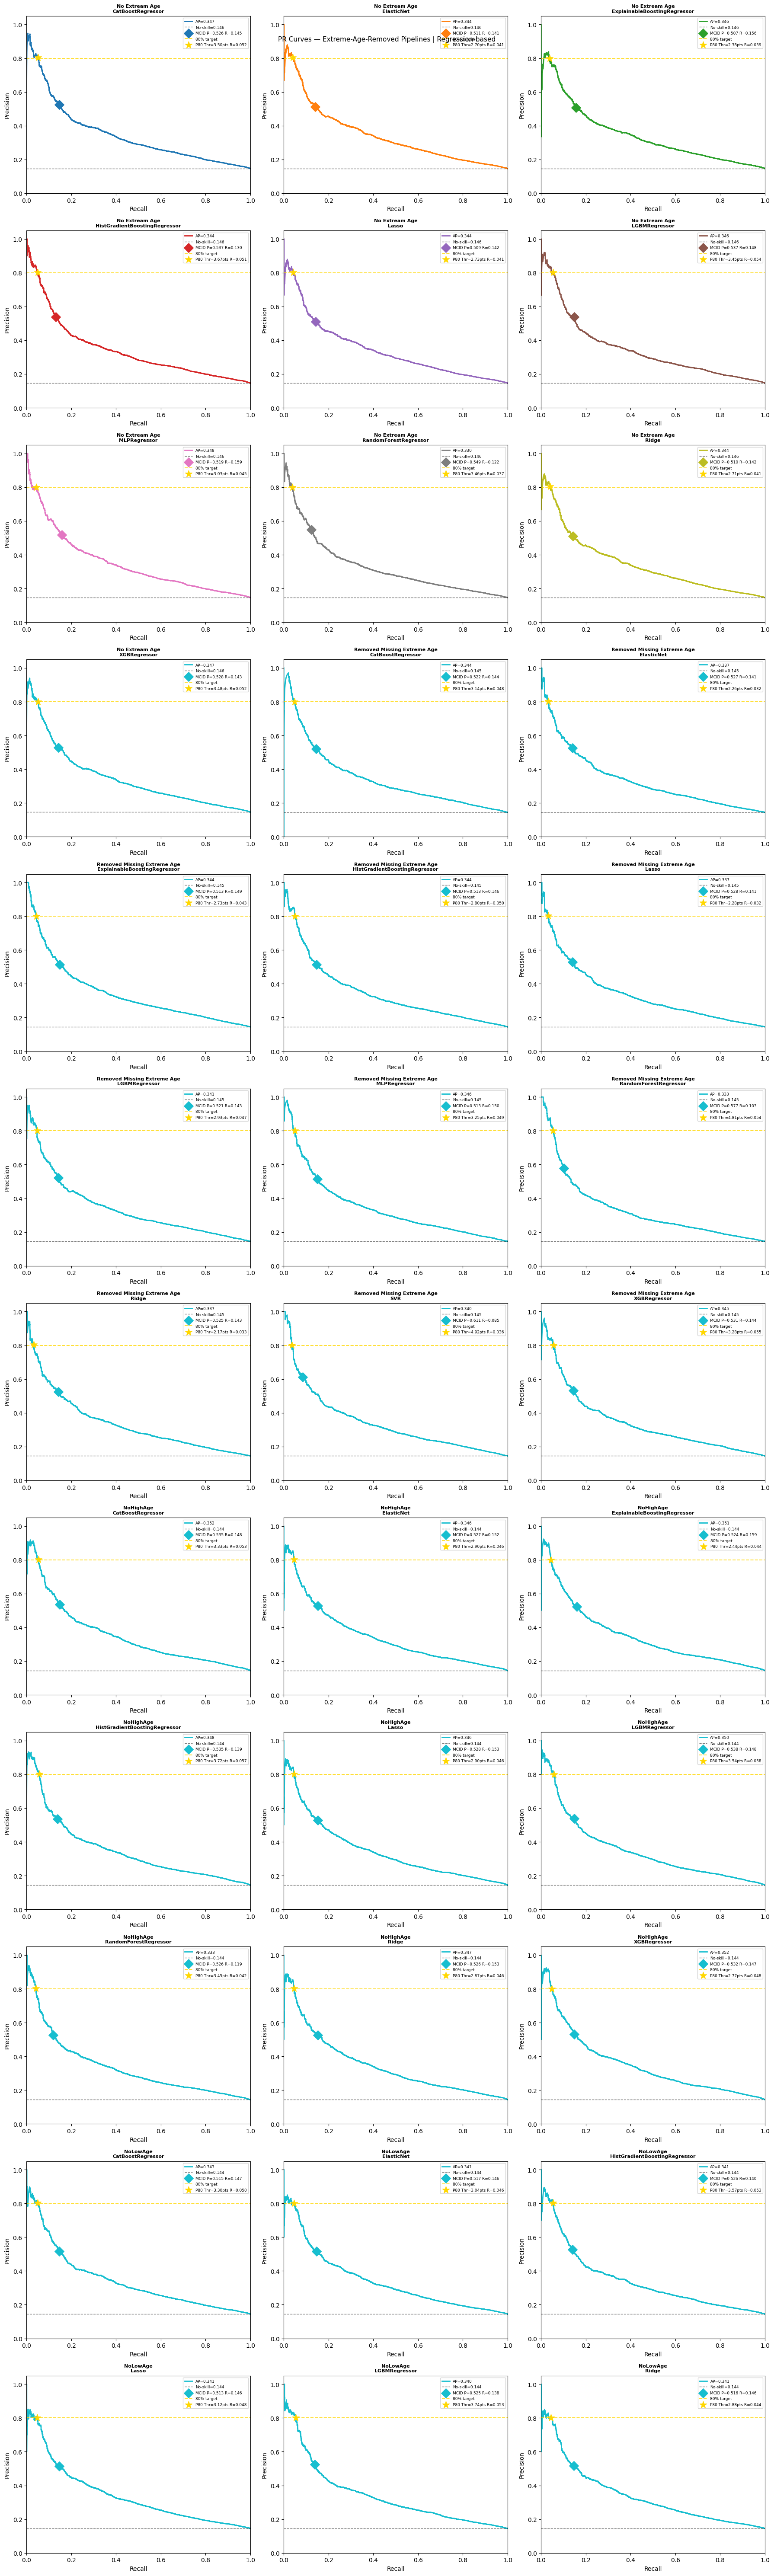

In [8]:
n_models = len(pr_summary)
if n_models == 0: print('No models.')
else:
    ncols = min(n_models, 3)
    nrows = (n_models + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    axes_flat = axes.flatten(); cmap = plt.get_cmap('tab10')
    for i, row in enumerate(pr_summary):
        ax = axes_flat[i]
        ax.plot(row['_rec_c'], row['_prec_c'], color=cmap(i), linewidth=2, label=f'AP={row["AP"]:.3f}')
        ax.axhline(row['_prev'], color='k', linestyle='--', linewidth=1, alpha=0.5, label=f'No-skill={row["_prev"]:.3f}')
        ax.scatter([row['_op_rec']], [row['_op_prec']], s=120, color=cmap(i), marker='D', zorder=6,
                   label=f'MCID P={row["_op_prec"]:.3f} R={row["_op_rec"]:.3f}')
        ax.axhline(TARGET_PRECISION, color='gold', linestyle='--', linewidth=1.4, alpha=0.8, label=f'{int(TARGET_PRECISION*100)}% target')
        if row['_tp_thr'] is not None:
            ax.scatter([row['_tp_rec']], [row['_tp_prec']], s=140, color='gold', marker='*', zorder=7,
                       label=f'P80 Thr={row["_tp_thr"]:.2f}pts R={row["_tp_rec"]:.3f}')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f'{row["Dataset"]}\n{row["Model"]}', fontsize=8, fontweight='bold')
        ax.legend(fontsize=6.5); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    for j in range(n_models, len(axes_flat)): axes_flat[j].set_visible(False)
    fig.suptitle('PR Curves — Extreme-Age-Removed Pipelines | Regression-based', fontsize=11)
    plt.tight_layout(); plt.show()

## 4. Confusion Matrix at MCID and P80 Threshold

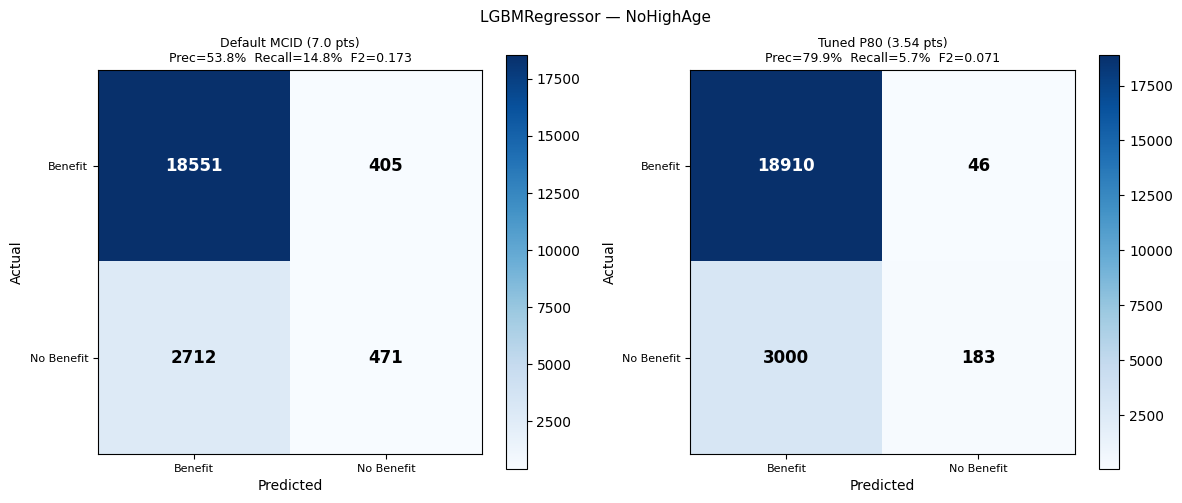

In [9]:
if not top_rows: print('No model reached 80% precision.')
else:
    best = top_rows[0]
    res  = all_results[best['Dataset']][best['Model']]
    yt, yp = res['y_test'], res['y_pred']
    v = ~np.isnan(yt); yt, yp = yt[v], yp[v]
    y_t_bin = (yt < MCID).astype(int)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (label, thr) in zip(axes, [
        (f'Default MCID ({MCID} pts)', MCID),
        (f'Tuned P80 ({best["_tp_thr"]:.2f} pts)', best['_tp_thr']),
    ]):
        yb = (yp < thr).astype(int)
        cm = confusion_matrix(y_t_bin, yb)
        prec = precision_score(y_t_bin, yb, zero_division=0)
        rec  = recall_score(y_t_bin, yb, zero_division=0)
        f2   = fbeta_score(y_t_bin, yb, beta=2, zero_division=0)
        im = ax.imshow(cm, cmap=plt.cm.Blues)
        ax.set_title(f'{label}\nPrec={prec:.1%}  Recall={rec:.1%}  F2={f2:.3f}', fontsize=9)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, format(cm[r,c],'d'), ha='center', va='center', fontsize=12,
                        color='white' if cm[r,c]>cm.max()/2 else 'black', fontweight='bold')
        ax.set_xticks([0,1]); ax.set_xticklabels(['Benefit','No Benefit'], fontsize=8)
        ax.set_yticks([0,1]); ax.set_yticklabels(['Benefit','No Benefit'], fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); plt.colorbar(im, ax=ax)
    fig.suptitle(f'{best["Model"]} — {best["Dataset"]}', fontsize=11)
    plt.tight_layout(); plt.show()

## 5. Bland-Altman

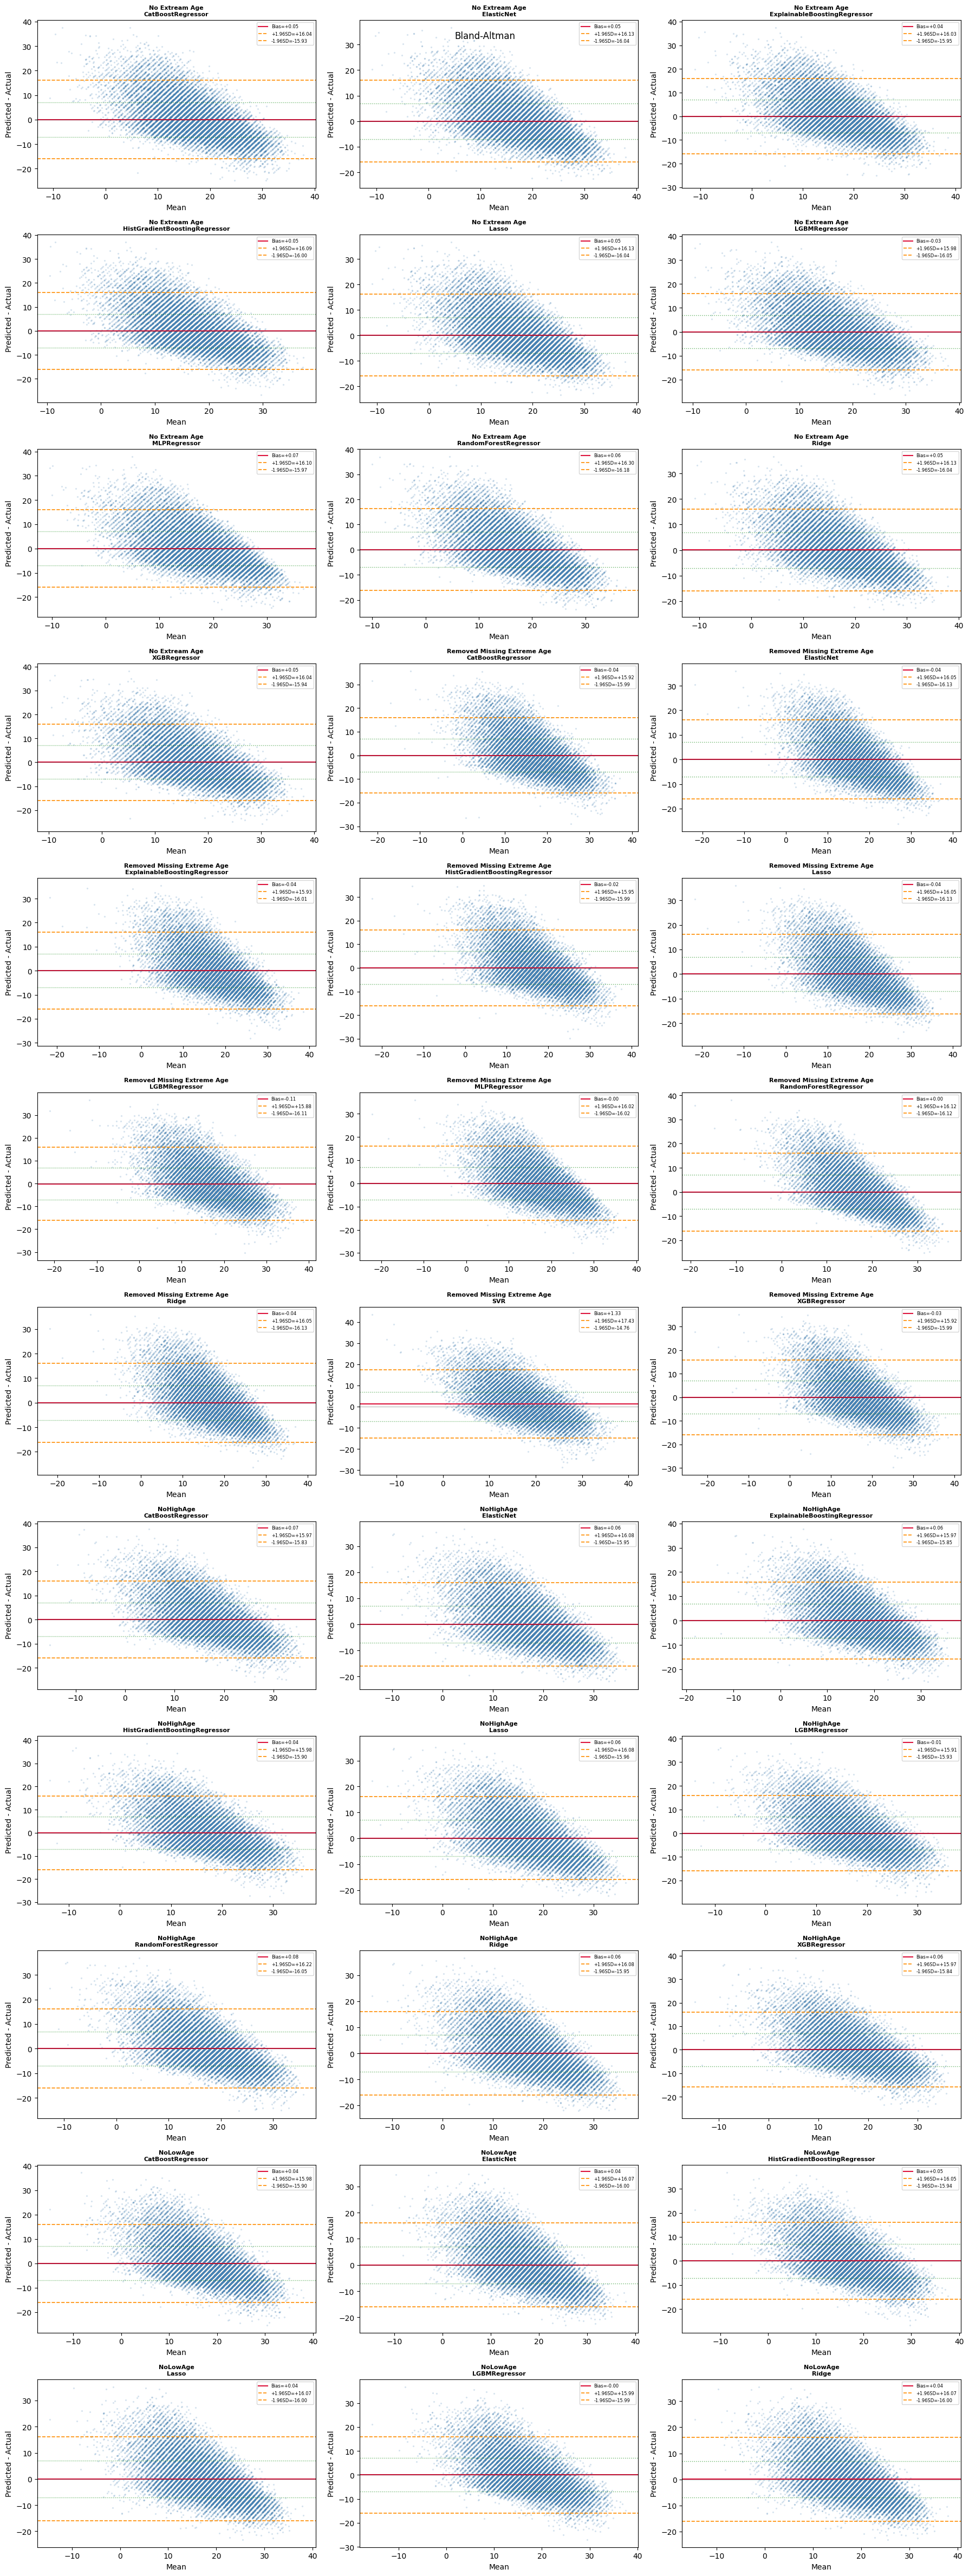

shape: (36, 5)
┌────────────────┬───────────────────────────────┬─────────┬───────────┬───────────┐
│ Dataset        ┆ Model                         ┆ Bias    ┆ LoA Upper ┆ LoA Lower │
│ ---            ┆ ---                           ┆ ---     ┆ ---       ┆ ---       │
│ str            ┆ str                           ┆ f64     ┆ f64       ┆ f64       │
╞════════════════╪═══════════════════════════════╪═════════╪═══════════╪═══════════╡
│ No Extream Age ┆ CatBoostRegressor             ┆ 0.0521  ┆ 16.037    ┆ -15.9327  │
│ No Extream Age ┆ ElasticNet                    ┆ 0.0463  ┆ 16.1289   ┆ -16.0363  │
│ No Extream Age ┆ ExplainableBoostingRegressor  ┆ 0.0408  ┆ 16.0272   ┆ -15.9456  │
│ No Extream Age ┆ HistGradientBoostingRegressor ┆ 0.0462  ┆ 16.0928   ┆ -16.0004  │
│ No Extream Age ┆ Lasso                         ┆ 0.0463  ┆ 16.131    ┆ -16.0385  │
│ …              ┆ …                             ┆ …       ┆ …         ┆ …         │
│ NoLowAge       ┆ ElasticNet                    ┆

In [10]:
n = len(pr_summary)
if n == 0: print('No models.')
else:
    ncols = min(n, 3); nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)
    axes_flat = axes.flatten(); ba_rows = []
    for i, row in enumerate(pr_summary):
        res = all_results[row['Dataset']][row['Model']]
        yt, yp = res['y_test'], res['y_pred']
        v = ~np.isnan(yt); yt, yp = yt[v], yp[v]
        diff = yp - yt; bias = float(np.mean(diff)); sd = float(np.std(diff))
        loa_u = bias + 1.96*sd; loa_l = bias - 1.96*sd
        ax = axes_flat[i]
        ax.scatter((yp+yt)/2, diff, s=2, alpha=0.15, color='steelblue')
        ax.axhline(bias,  color='crimson',    linestyle='-',  linewidth=1.5, label=f'Bias={bias:+.2f}')
        ax.axhline(loa_u, color='darkorange', linestyle='--', linewidth=1.2, label=f'+1.96SD={loa_u:+.2f}')
        ax.axhline(loa_l, color='darkorange', linestyle='--', linewidth=1.2, label=f'-1.96SD={loa_l:+.2f}')
        ax.axhline( MCID, color='green', linestyle=':', linewidth=1.0, alpha=0.6)
        ax.axhline(-MCID, color='green', linestyle=':', linewidth=1.0, alpha=0.6)
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
        ax.set_xlabel('Mean'); ax.set_ylabel('Predicted - Actual')
        ax.set_title(f'{row["Dataset"]}\n{row["Model"]}', fontsize=8, fontweight='bold')
        ax.legend(fontsize=6)
        ba_rows.append({'Dataset': row['Dataset'], 'Model': row['Model'],
                        'Bias': round(bias,4), 'LoA Upper': round(loa_u,4), 'LoA Lower': round(loa_l,4)})
    for j in range(n, len(axes_flat)): axes_flat[j].set_visible(False)
    fig.suptitle('Bland-Altman', fontsize=12)
    plt.tight_layout(); plt.show()
    print(pl.DataFrame(ba_rows))

## 6. Regression Performance

In [11]:
perf_rows = []
for ds, models_dict in all_results.items():
    for mdl, res in models_dict.items():
        perf_rows.append({'Dataset': ds, 'Model': mdl,
                          'RMSE': round(res['test_rmse'],4), 'MAE': round(res['test_mae'],4), 'R2': round(res['test_r2'],4)})
print(pl.DataFrame(perf_rows).sort('RMSE'))

shape: (36, 5)
┌─────────────────────────────┬───────────────────────────────┬────────┬────────┬────────┐
│ Dataset                     ┆ Model                         ┆ RMSE   ┆ MAE    ┆ R2     │
│ ---                         ┆ ---                           ┆ ---    ┆ ---    ┆ ---    │
│ str                         ┆ str                           ┆ f64    ┆ f64    ┆ f64    │
╞═════════════════════════════╪═══════════════════════════════╪════════╪════════╪════════╡
│ NoHighAge                   ┆ CatBoostRegressor             ┆ 8.114  ┆ 6.4034 ┆ 0.3034 │
│ NoHighAge                   ┆ XGBRegressor                  ┆ 8.1143 ┆ 6.3998 ┆ 0.3034 │
│ NoHighAge                   ┆ ExplainableBoostingRegressor  ┆ 8.1169 ┆ 6.4064 ┆ 0.3029 │
│ NoHighAge                   ┆ LGBMRegressor                 ┆ 8.124  ┆ 6.4178 ┆ 0.3017 │
│ NoHighAge                   ┆ HistGradientBoostingRegressor ┆ 8.1328 ┆ 6.42   ┆ 0.3002 │
│ …                           ┆ …                             ┆ …      ┆ … 

## 7. Final Recommendation

In [12]:
print('=' * 70)
print('FINAL RECOMMENDATION — Regression-based approach')
print('=' * 70)
print(f'Business ask  : Remove extreme age (40-49, 90-120)')
print(f'Clinical goal : {int(TARGET_PRECISION*100)}% Precision | Highest Recall | Threshold close to MCID={MCID}')
print()
if not top_rows:
    print('No model reached 80% precision.')
    print('Next step: see notebook 4.3 — balanced classification approach.')
else:
    best = top_rows[0]
    print(f'Model         : {best["Model"]}')
    print(f'Dataset       : {best["Dataset"]}')
    print(f'Precision@P80 : {best["_tp_prec"]:.1%}')
    print(f'Recall@P80    : {best["_tp_rec"]:.1%}')
    print(f'Threshold     : {best["_tp_thr"]:.3f} pts  (MCID={MCID}, distance={abs(MCID-best["_tp_thr"]):.3f} pts)')
    print(f'AP            : {best["AP"]}')
    print()
    print('All candidates reaching 80% precision (sorted by Recall):')
    print(f'{"#":<3} {"Dataset":<35} {"Model":<35} {"Thr":<8} {"Recall"}')
    print('-' * 90)
    for i, r in enumerate(top_rows):
        marker = ' <- BEST' if i == 0 else ''
        print(f'{i+1:<3} {r["Dataset"]:<35} {r["Model"]:<35} {r["_tp_thr"]:<8.3f} {r["_tp_rec"]:.3f}{marker}')
    print()
    print('NOTE: Recall is ~5% with regression-based models.')
    print('For higher recall, see notebook 4.3 (balanced classifiers on all extreme-age datasets).')

FINAL RECOMMENDATION — Regression-based approach
Business ask  : Remove extreme age (40-49, 90-120)
Clinical goal : 80% Precision | Highest Recall | Threshold close to MCID=7.0

Model         : LGBMRegressor
Dataset       : NoHighAge
Precision@P80 : 80.0%
Recall@P80    : 5.8%
Threshold     : 3.541 pts  (MCID=7.0, distance=3.459 pts)
AP            : 0.3499

All candidates reaching 80% precision (sorted by Recall):
#   Dataset                             Model                               Thr      Recall
------------------------------------------------------------------------------------------
1   NoHighAge                           LGBMRegressor                       3.541    0.058 <- BEST
2   NoHighAge                           HistGradientBoostingRegressor       3.716    0.057
3   Removed Missing Extreme Age         XGBRegressor                        3.279    0.055
4   Removed Missing Extreme Age         RandomForestRegressor               4.810    0.054
5   No Extream Age          